#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** DIP Lab 04                                                                        
***Date:*** 19/02/2026

#**Task 01**

Saving download.jpg to download.jpg
Task 1: Denoised X-ray (Noise Removed)


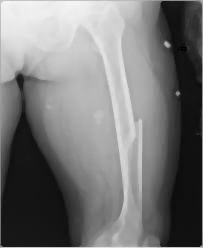

In [1]:
from google.colab import files
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
xray_img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_GRAYSCALE)

# 1. Remove Noise using Median Filter (kernel size 5)
denoised_xray = cv2.medianBlur(xray_img, 5)

print("Task 1: Denoised X-ray (Noise Removed)")
cv2_imshow(denoised_xray)

Task 2: Enhanced X-ray (Fractures Highlighted)


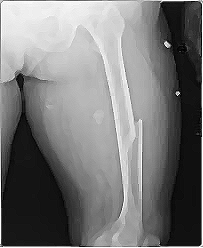

In [2]:
# 2. Enhance Edges using the Laplacian operator
laplacian = cv2.Laplacian(denoised_xray, cv2.CV_64F)
enhanced_xray = cv2.convertScaleAbs(denoised_xray - laplacian)

print("Task 2: Enhanced X-ray (Fractures Highlighted)")
cv2_imshow(enhanced_xray)

#**Task 02**

Saving 1_6re7C4KsI56LxevEaOWy_g.jpg to 1_6re7C4KsI56LxevEaOWy_g.jpg
Task 1: Smoothed Image (Shadows/Reflections Reduced)


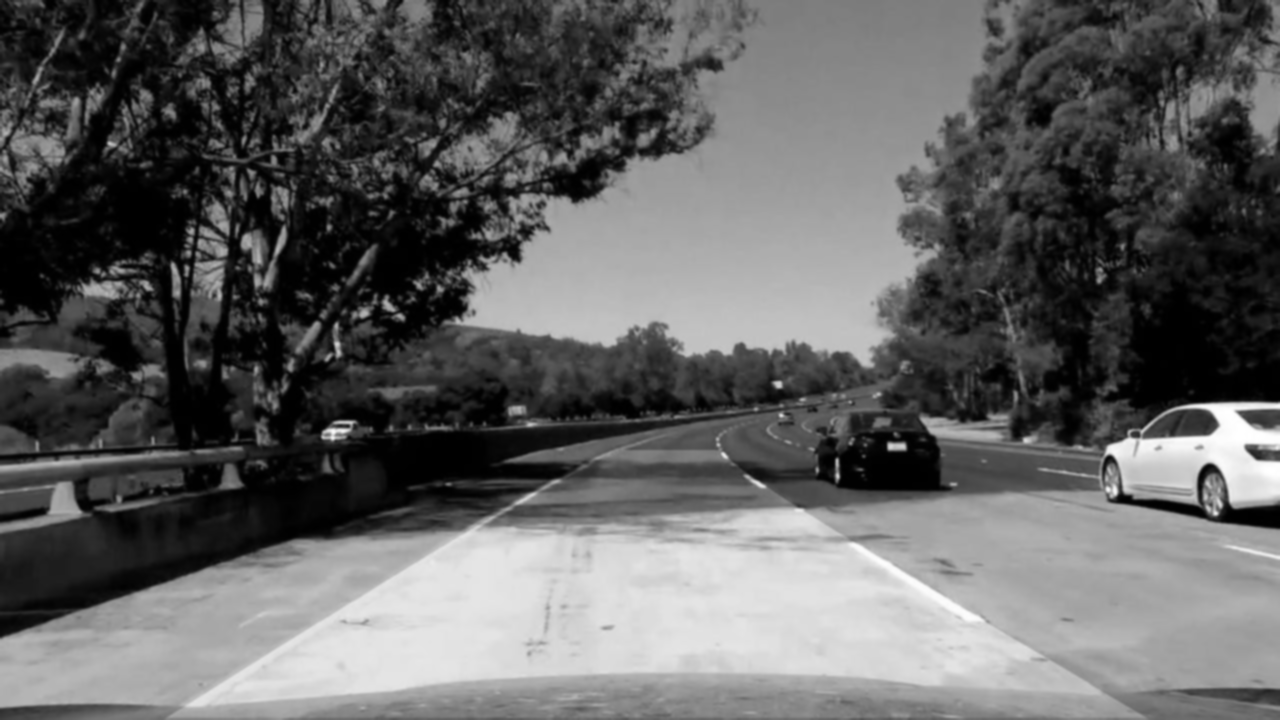

In [3]:
from google.colab import files
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Upload Road/Lane image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
road_img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)
road_gray = cv2.cvtColor(road_img, cv2.COLOR_BGR2GRAY)

# 1. Smooth the image using Gaussian Blur
# This removes "high-frequency" noise like reflections
smoothed_road = cv2.GaussianBlur(road_gray, (5, 5), 0)

print("Task 1: Smoothed Image (Shadows/Reflections Reduced)")
cv2_imshow(smoothed_road)

Task 2: Detected Lane Markings and Boundaries


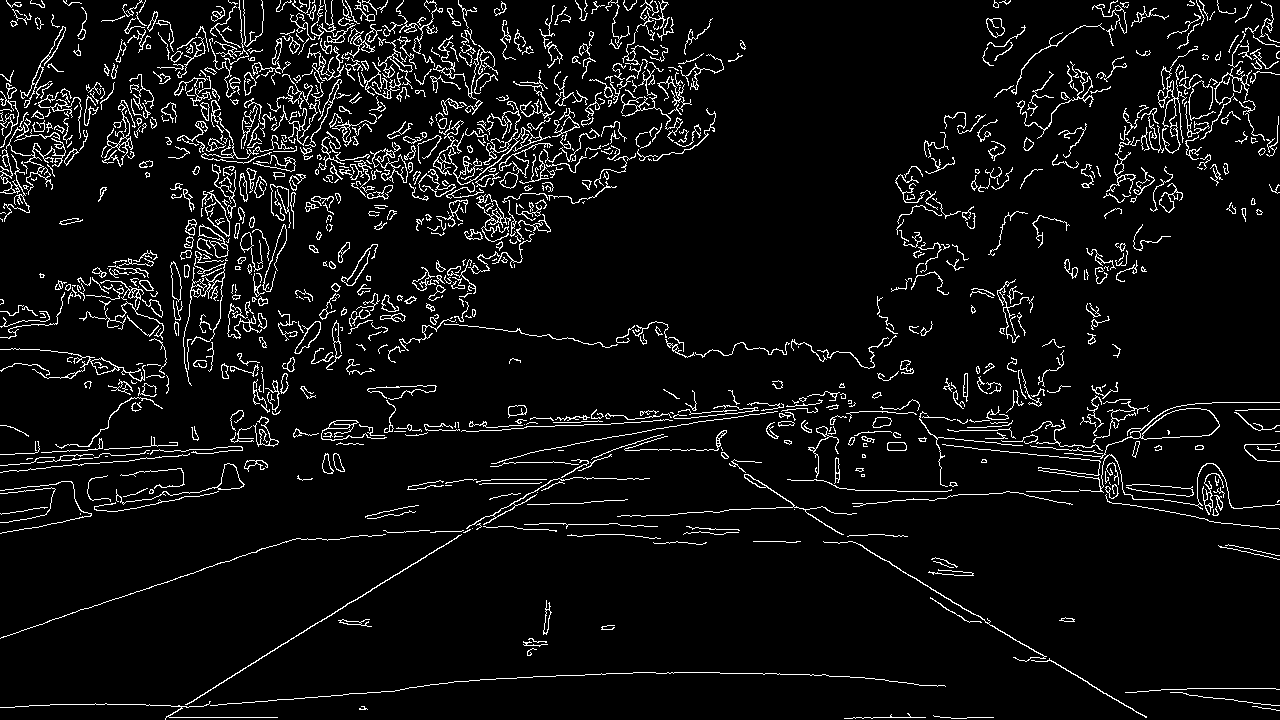

In [4]:
# 2. Detect Edges using Canny
# Low and high thresholds help isolate strong lane lines
lane_edges = cv2.Canny(smoothed_road, 50, 150)

print("Task 2: Detected Lane Markings and Boundaries")
cv2_imshow(lane_edges)

Task 3: Edge-Preserving Noise Reduction


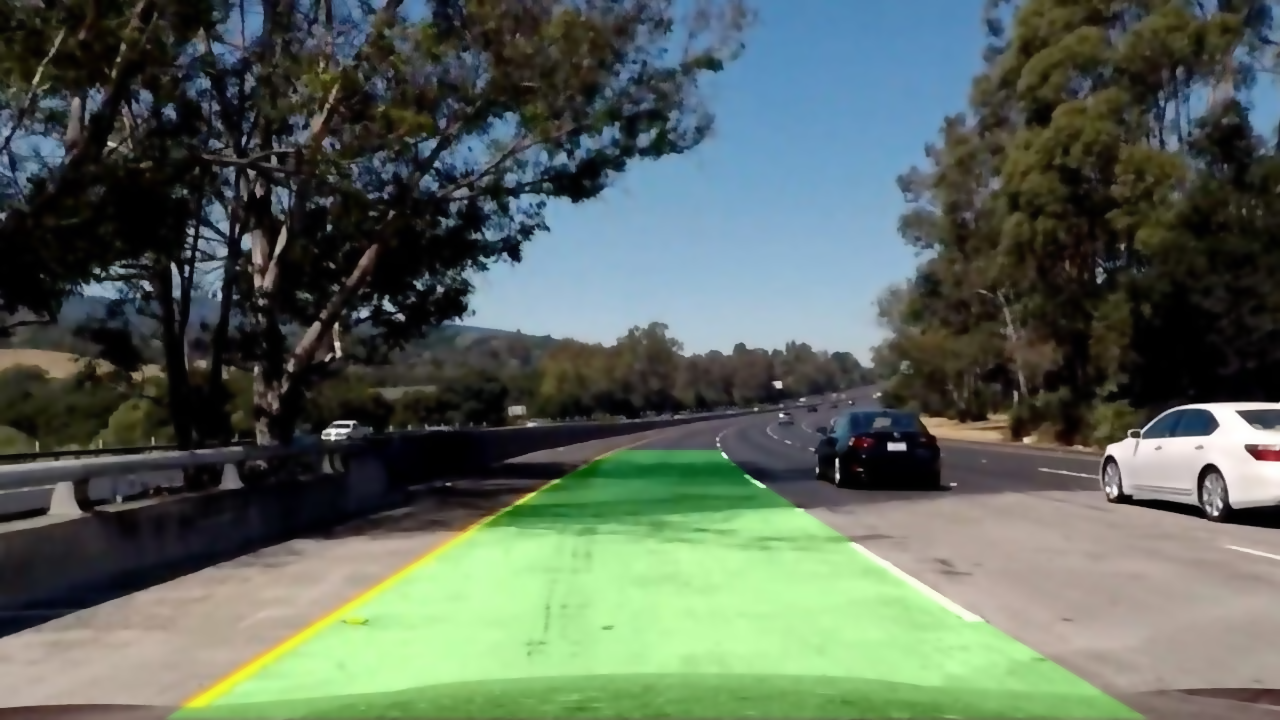

In [5]:
# 3. Bilateral Filter for Object Detection
object_friendly_img = cv2.bilateralFilter(road_img, 9, 75, 75)

print("Task 3: Edge-Preserving Noise Reduction")
cv2_imshow(object_friendly_img)

#**Task 03**

Saving images.jpg to images.jpg
Task 1: General Smoothing (Grain Reduced)


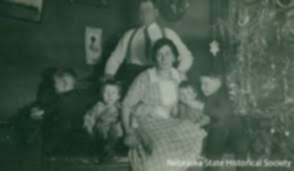

In [6]:
from google.colab import files
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Upload the old/blurry photograph
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
old_photo = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)

# 1. Reduce general noise using Gaussian Blur
general_smooth = cv2.GaussianBlur(old_photo, (5, 5), 0)

print("Task 1: General Smoothing (Grain Reduced)")
cv2_imshow(general_smooth)

Task 2: Fine-Grain Removal (Features Preserved)


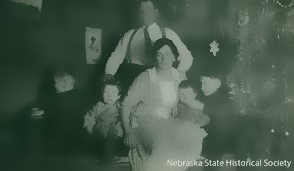

In [7]:
# 2. Advanced Noise Removal while maintaining clarity
# Bilateral filtering is the gold standard for photo restoration
restored_photo = cv2.bilateralFilter(old_photo, 15, 75, 75)

print("Task 2: Fine-Grain Removal (Features Preserved)")
cv2_imshow(restored_photo)

Task 3: Final Restored and Sharpened Photo


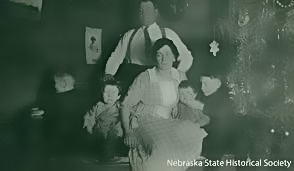

In [8]:
# Task 3: Sharpening the faces and objects
gaussian_blur = cv2.GaussianBlur(restored_photo, (9, 9), 10.0)

# The 'Unsharp Mask' is the result of weighted addition
sharpened_photo = cv2.addWeighted(restored_photo, 1.5, gaussian_blur, -0.5, 0)

print("Task 3: Final Restored and Sharpened Photo")
cv2_imshow(sharpened_photo)

#**Task 04**

Saving images (1).jpg to images (1).jpg
Task 1: Denoised Fingerprint


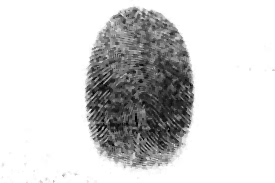

In [9]:
from google.colab import files
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read as grayscale
finger_img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_GRAYSCALE)

# 1. Remove smudges and noise
# Median filter is perfect for removing small black/white spots
denoised_finger = cv2.medianBlur(finger_img, 3)

print("Task 1: Denoised Fingerprint")
cv2_imshow(denoised_finger)

Task 2: Contrast Enhanced Fingerprint


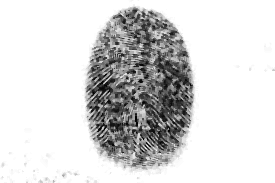

In [10]:
# 2. Improve Contrast and smooth variations
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced_contrast = clahe.apply(denoised_finger)

print("Task 2: Contrast Enhanced Fingerprint")
cv2_imshow(enhanced_contrast)

Task 3: Final Ridge Enhancement


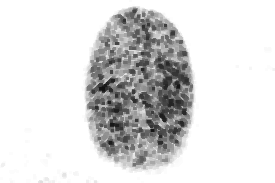

In [11]:
# 3. Enhance Ridge Patterns
# Using a morphological kernel to thicken and connect ridge lines
kernel = np.ones((3,3), np.uint8)
ridge_enhanced = cv2.morphologyEx(enhanced_contrast, cv2.MORPH_CLOSE, kernel)

print("Task 3: Final Ridge Enhancement")
cv2_imshow(ridge_enhanced)